# Story 2: Dấu hiệu Tử vong của Khách hàng

**Claims cần chứng minh:**
1. RFM segmentation: 27.7% Never Purchased, 20.1% Champions, 10.9% At Risk, 7.6% Lost
2. Return (OK Review) có churn rate cao nhất (24.7%), **không phải** Return+Low Review
3. Giải thích tại sao counterintuitive đó xảy ra (selection bias)
4. 1,969 At Risk + recent return = 14.9% của At Risk pool

**Data:** `orders.csv`, `payments.csv`, `returns.csv`, `reviews.csv`, `shipments.csv`, `customers.csv`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 120

RAW = '../src/data/raw/'
orders    = pd.read_csv(RAW+'orders.csv',    parse_dates=['order_date'])
payments  = pd.read_csv(RAW+'payments.csv')
returns   = pd.read_csv(RAW+'returns.csv',   parse_dates=['return_date'])
reviews   = pd.read_csv(RAW+'reviews.csv',   parse_dates=['review_date'])
shipments = pd.read_csv(RAW+'shipments.csv', parse_dates=['ship_date','delivery_date'])
customers = pd.read_csv(RAW+'customers.csv')

print(f"orders:    {len(orders):,} rows")
print(f"customers: {len(customers):,} rows")
print(f"returns:   {len(returns):,} rows")
print(f"reviews:   {len(reviews):,} rows")
print(f"Order statuses: {sorted(orders.order_status.unique())}")

orders:    646,945 rows
customers: 121,930 rows
returns:   39,939 rows
reviews:   113,551 rows
Order statuses: ['cancelled', 'created', 'delivered', 'paid', 'returned', 'shipped']


## Step 1: RFM Computation

**Rule:** Loại `cancelled` orders. Monetary = `payment_value` (số tiền thực trả), không phải line revenue.

In [2]:
snapshot_date = orders['order_date'].max()
print(f"Snapshot date: {snapshot_date.date()}")

active = orders[orders['order_status'] != 'cancelled'].copy()
cust_pay = active.merge(payments[['order_id','payment_value']], on='order_id', how='left')

rfm = cust_pay.groupby('customer_id').agg(
    recency_days = ('order_date', lambda x: (snapshot_date - x.max()).days),
    frequency    = ('order_id',   'nunique'),
    monetary     = ('payment_value', 'sum')
).reset_index()

print(f"\nCustomers with active orders: {len(rfm):,}")
print(f"Total customers in system:   {len(customers):,}")
print(f"Never purchased:             {len(customers) - len(rfm):,}")
print(f"\nRFM stats:")
print(rfm[['recency_days','frequency','monetary']].describe().round(1))

Snapshot date: 2022-12-31



Customers with active orders: 88,123
Total customers in system:   121,930
Never purchased:             33,807

RFM stats:
       recency_days  frequency   monetary
count       88123.0    88123.0    88123.0
mean         1282.0        6.7   161522.6
std          1030.6        7.9   200847.1
min             0.0        1.0      445.6
25%           325.0        1.0    30080.4
50%          1018.0        4.0    85345.9
75%          2020.0        9.0   217989.7
max          3832.0      100.0  3336864.8


In [3]:
# Quintile scoring
rfm['R_score'] = pd.qcut(rfm['recency_days'],               q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)

# Show quintile boundaries
print("R_score bins (recency_days):")
print(pd.qcut(rfm['recency_days'], q=5, labels=[5,4,3,2,1]).value_counts().sort_index())
print(f"\nRecency quintile boundaries (days):")
print(pd.qcut(rfm['recency_days'], q=5).value_counts().sort_index())

R_score bins (recency_days):
recency_days
5    17631
4    17625
3    17650
2    17593
1    17624
Name: count, dtype: int64

Recency quintile boundaries (days):
recency_days
(-0.001, 256.0]     17631
(256.0, 678.0]      17625
(678.0, 1464.0]     17650
(1464.0, 2261.0]    17593
(2261.0, 3832.0]    17624
Name: count, dtype: int64


In [4]:
def rfm_segment(row):
    r, f = row['R_score'], row['F_score']
    if r >= 4 and f >= 4: return 'Champions'
    if r >= 3 and f >= 3: return 'Loyal Customers'
    if r >= 4 and f <= 2: return 'New Customers'
    if r >= 3 and f <= 2: return 'Potential Loyalists'
    if r == 2 and f >= 2: return 'At Risk'
    if r <= 2 and f >= 3: return 'About To Sleep'
    if r == 1 and f == 1: return 'Lost'
    return 'Others'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

# Add Never Purchased
all_custs = customers[['customer_id']].merge(rfm, on='customer_id', how='left')
all_custs['segment'] = all_custs['segment'].fillna('Never Purchased')

# Segment counts
seg_order = ['Never Purchased','Champions','Loyal Customers','At Risk',
             'Others','Lost','Potential Loyalists','New Customers','About To Sleep']
seg_counts = all_custs.groupby('segment').size().reindex(seg_order).fillna(0).astype(int)
total = len(all_custs)

print(f"{'Segment':<25} {'Count':>8} {'%':>7}")
print('-' * 42)
for seg, cnt in seg_counts.items():
    print(f"{seg:<25} {cnt:>8,} {cnt/total*100:>6.1f}%")
print(f"{'TOTAL':<25} {total:>8,} {'100.0%':>7}")

Segment                      Count       %
------------------------------------------
Never Purchased             33,807   27.7%
Champions                   24,490   20.1%
Loyal Customers             18,163   14.9%
At Risk                     13,250   10.9%
Others                      10,533    8.6%
Lost                         9,244    7.6%
Potential Loyalists          5,388    4.4%
New Customers                4,865    4.0%
About To Sleep               2,190    1.8%
TOTAL                      121,930  100.0%


In [5]:
# Monetary stats by segment
seg_monetary = rfm.groupby('segment')['monetary'].agg(['mean','median','sum']).round(0)
seg_monetary.columns = ['avg_monetary','median_monetary','total_monetary']
seg_monetary['avg_monetary_K'] = seg_monetary['avg_monetary'] / 1000
print("Monetary stats (payment_value) by segment:")
print(seg_monetary.sort_values('avg_monetary', ascending=False).to_string())

Monetary stats (payment_value) by segment:
                     avg_monetary  median_monetary  total_monetary  avg_monetary_K
segment                                                                           
Champions                372804.0         309670.0    9.129976e+09         372.804
Loyal Customers          155835.0         120813.0    2.830439e+09         155.835
At Risk                   87868.0          66473.0    1.164246e+09          87.868
About To Sleep            82850.0          72649.0    1.814414e+08          82.850
New Customers             41793.0          32289.0    2.033228e+08          41.793
Potential Loyalists       38171.0          30528.0    2.056635e+08          38.171
Others                    29474.0          21737.0    3.104456e+08          29.474
Lost                      22536.0          15513.0    2.083208e+08          22.536


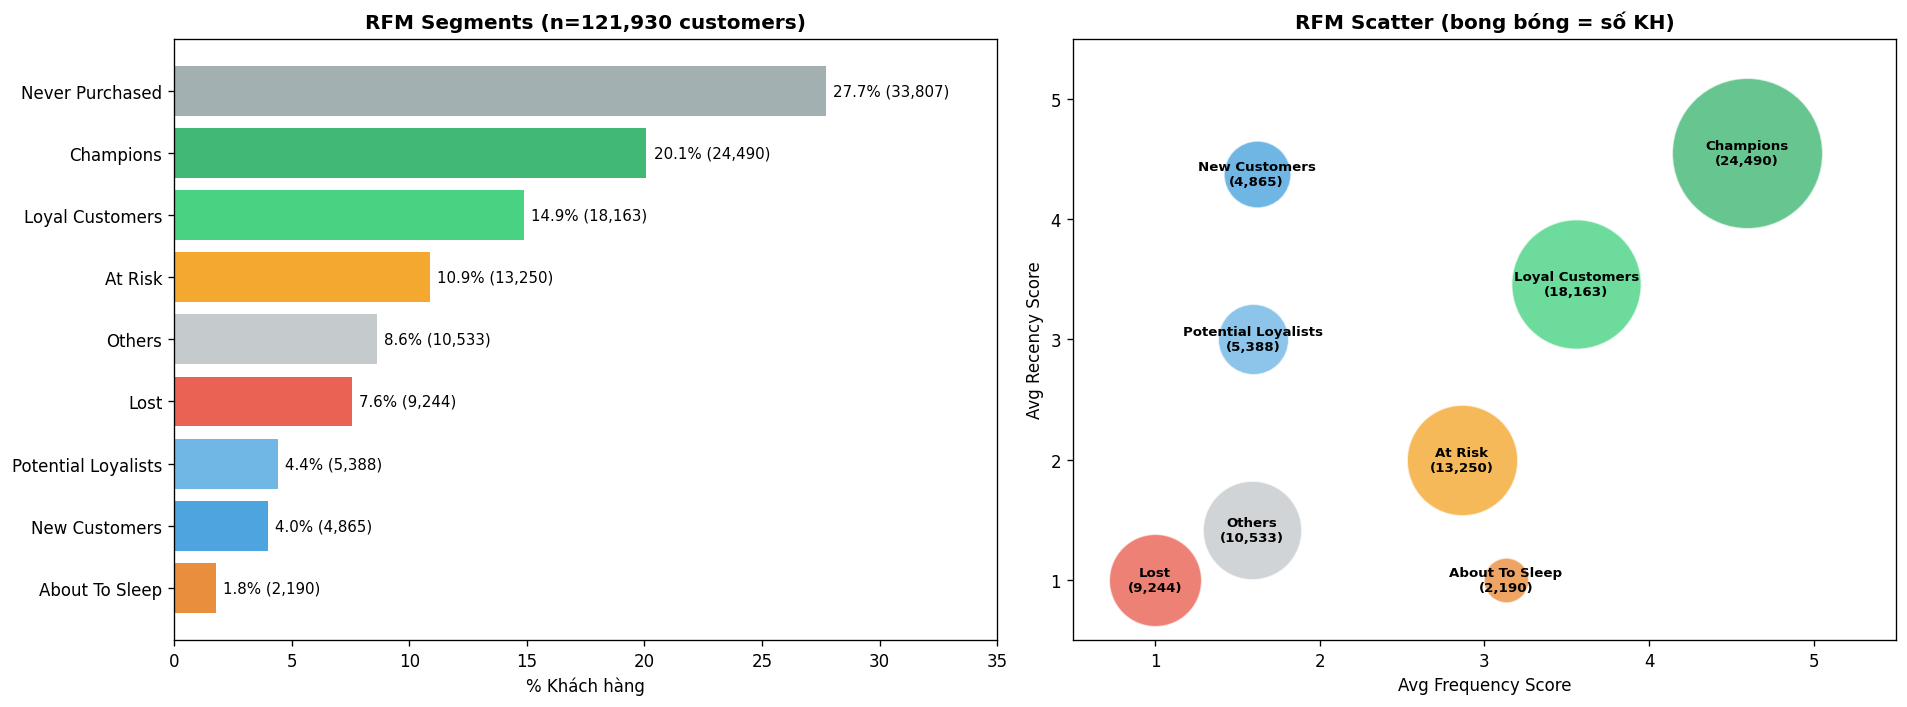

In [6]:
# Visualize segments
seg_colors = {
    'Champions': '#27AE60', 'Loyal Customers': '#2ECC71',
    'New Customers': '#3498DB', 'Potential Loyalists': '#5DADE2',
    'At Risk': '#F39C12', 'About To Sleep': '#E67E22',
    'Lost': '#E74C3C', 'Never Purchased': '#95A5A6', 'Others': '#BDC3C7'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar chart
sc = seg_counts.sort_values(ascending=True)
bars = ax1.barh(sc.index, sc.values / total * 100,
                color=[seg_colors.get(s,'gray') for s in sc.index], alpha=0.88)
for bar, (seg, cnt) in zip(bars, sc.items()):
    ax1.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             f"{cnt/total*100:.1f}% ({cnt:,})", va='center', fontsize=9)
ax1.set_xlabel('% Khách hàng'); ax1.set_xlim(0, 35)
ax1.set_title(f'RFM Segments (n={total:,} customers)', fontweight='bold')

# Scatter: R_score vs F_score colored by segment
seg_scatter = rfm.groupby('segment').agg(
    r=('R_score','mean'), f=('F_score','mean'),
    n=('customer_id','count'), m=('monetary','mean')
).reset_index()
for _, row in seg_scatter.iterrows():
    c = seg_colors.get(row['segment'], 'gray')
    ax2.scatter(row['f'], row['r'], s=row['n']/3, color=c, alpha=0.7, edgecolors='white')
    ax2.annotate(f"{row['segment']}\n({row['n']:,})", (row['f'], row['r']),
                 ha='center', va='center', fontsize=8, fontweight='bold')
ax2.set_xlabel('Avg Frequency Score'); ax2.set_ylabel('Avg Recency Score')
ax2.set_title('RFM Scatter (bong bóng = số KH)', fontweight='bold')
ax2.set_xlim(0.5, 5.5); ax2.set_ylim(0.5, 5.5)
plt.tight_layout(); plt.show()

## Step 2: Experience Classification

Phân loại dựa trên **3 đơn gần nhất** của mỗi khách hàng:
- Giao trễ: `delivery_date - ship_date > 7 ngày`
- Trả hàng: `order_id` xuất hiện trong `returns.csv`
- Review xấu: `rating <= 2` trong `reviews.csv`

In [7]:
# Build lookup sets
late_ids    = set(shipments[(shipments['delivery_date']-shipments['ship_date']).dt.days > 7]['order_id'].dropna())
return_ids  = set(returns['order_id'].dropna())
lowrev_ids  = set(reviews[reviews['rating'] <= 2]['order_id'].dropna())

print(f"Late delivery orders:    {len(late_ids):,}")
print(f"Returned orders:         {len(return_ids):,}")
print(f"Low review orders:       {len(lowrev_ids):,}")

# Last 3 orders per customer
last3 = active.sort_values('order_date').groupby('customer_id').tail(3)
print(f"\nLast-3-orders rows: {len(last3):,} (across {last3.customer_id.nunique():,} customers)")

Late delivery orders:    0
Returned orders:         36,062
Low review orders:       14,825

Last-3-orders rows: 206,570 (across 88,123 customers)


In [8]:
def classify(grp):
    oids = set(grp['order_id'].values)
    has_ret = bool(oids & return_ids)
    has_low = bool(oids & lowrev_ids)
    has_lat = bool(oids & late_ids)
    if has_ret and has_low: return 'Return + Low Review'
    if has_ret:             return 'Return (OK Review)'
    if has_lat:             return 'Late Delivery'
    return 'No Issues'

exp = last3.groupby('customer_id').apply(classify, include_groups=False).reset_index()
exp.columns = ['customer_id', 'experience_group']

print("Experience group distribution:")
print(exp['experience_group'].value_counts())

Experience group distribution:
experience_group
No Issues              76028
Return (OK Review)     11628
Return + Low Review      467
Name: count, dtype: int64


In [9]:
# Merge với RFM
rfm_exp = rfm.merge(exp, on='customer_id', how='left')
rfm_exp['experience_group'] = rfm_exp['experience_group'].fillna('No Issues')

churn_segs = ['At Risk', 'About To Sleep', 'Lost']
rfm_exp['is_churn'] = rfm_exp['segment'].isin(churn_segs)
rfm_exp['is_lost']  = rfm_exp['segment'] == 'Lost'

churn_by_exp = rfm_exp.groupby('experience_group').agg(
    n            = ('customer_id', 'count'),
    churn_rate   = ('is_churn',    'mean'),
    lost_rate    = ('is_lost',     'mean')
).reset_index()
churn_by_exp['churn_pct'] = churn_by_exp['churn_rate'] * 100
churn_by_exp['lost_pct']  = churn_by_exp['lost_rate']  * 100

print("\nChurn rate by experience group:")
print(churn_by_exp.sort_values('churn_pct', ascending=False).to_string())


Churn rate by experience group:
      experience_group      n  churn_rate  lost_rate  churn_pct   lost_pct
0            No Issues  76028    0.285829   0.114103  28.582891  11.410270
1   Return (OK Review)  11628    0.246990   0.048934  24.699002   4.893361
2  Return + Low Review    467    0.173448   0.000000  17.344754   0.000000


posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


posx and posy should be finite values


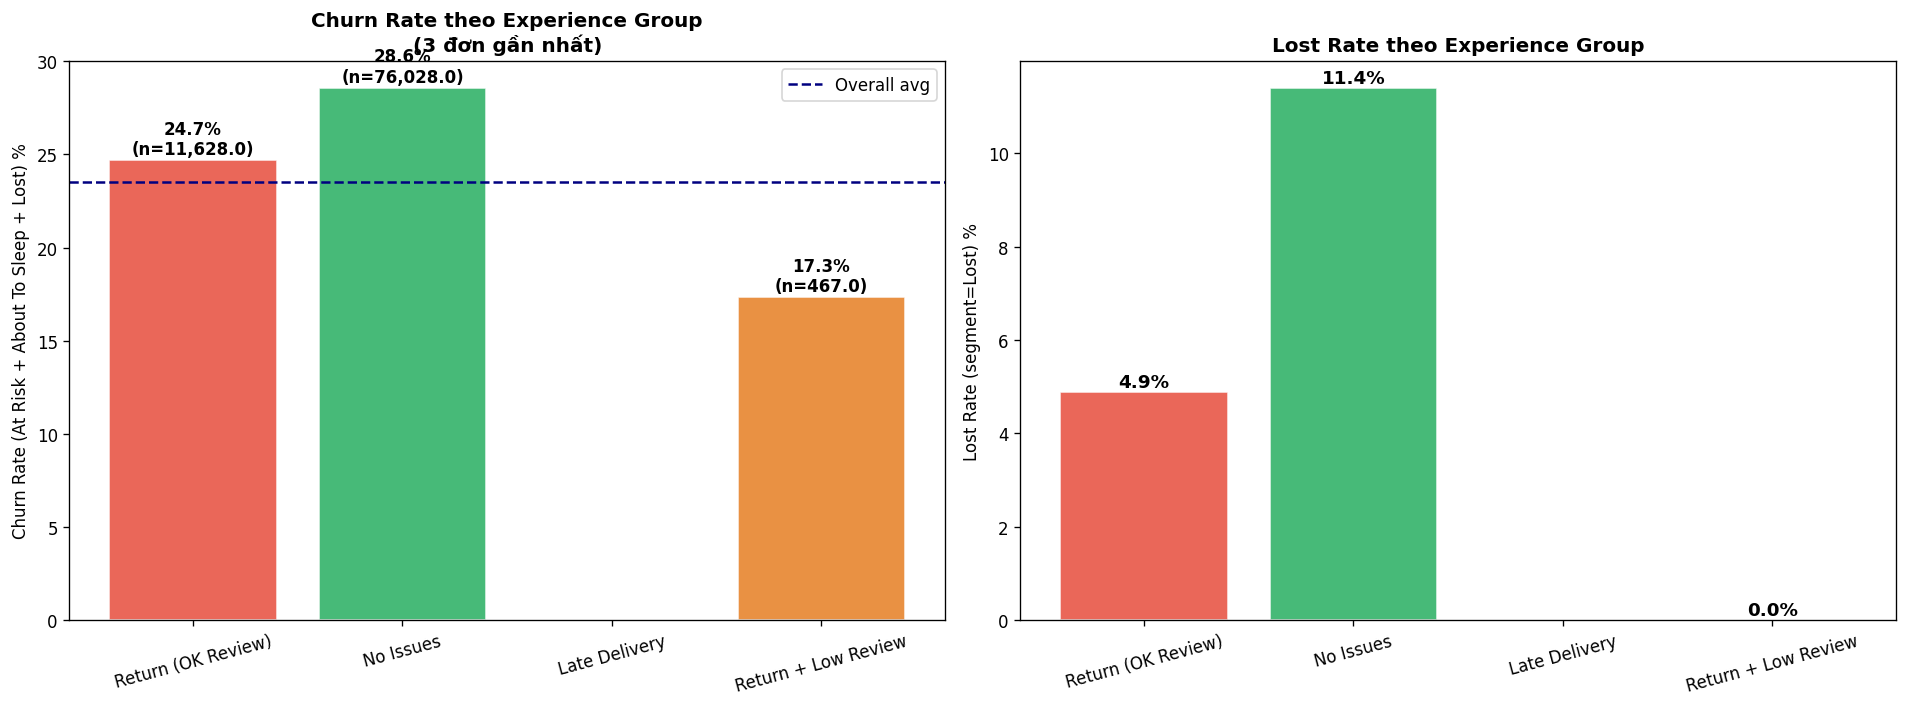


⚠️  COUNTERINTUITIVE: 'Return + Low Review' có churn rate THẤP HƠN 'Return (OK Review)'
     Giải thích ở bước tiếp theo...


In [10]:
exp_order = ['Return (OK Review)', 'No Issues', 'Late Delivery', 'Return + Low Review']
cb = churn_by_exp.set_index('experience_group').reindex(exp_order)
exp_colors = {'Return (OK Review)':'#E74C3C', 'No Issues':'#27AE60',
              'Late Delivery':'#F39C12', 'Return + Low Review':'#E67E22'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Churn rate
bars = ax1.bar(cb.index, cb['churn_pct'],
               color=[exp_colors[e] for e in cb.index], alpha=0.85, edgecolor='white')
for bar, (exp, row) in zip(bars, cb.iterrows()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"{row['churn_pct']:.1f}%\n(n={row['n']:,})", ha='center', fontsize=10, fontweight='bold')
ax1.axhline(churn_by_exp['churn_pct'].mean(), color='navy', ls='--', lw=1.5, label='Overall avg')
ax1.set_ylabel('Churn Rate (At Risk + About To Sleep + Lost) %')
ax1.set_title('Churn Rate theo Experience Group\n(3 đơn gần nhất)', fontweight='bold')
ax1.tick_params(axis='x', rotation=15); ax1.legend()

# Lost rate
bars2 = ax2.bar(cb.index, cb['lost_pct'],
                color=[exp_colors[e] for e in cb.index], alpha=0.85, edgecolor='white')
for bar, (exp, row) in zip(bars2, cb.iterrows()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{row['lost_pct']:.1f}%", ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Lost Rate (segment=Lost) %')
ax2.set_title('Lost Rate theo Experience Group', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

print("\n⚠️  COUNTERINTUITIVE: 'Return + Low Review' có churn rate THẤP HƠN 'Return (OK Review)'")
print("     Giải thích ở bước tiếp theo...")

## Step 3: Giải thích Selection Bias

Tại sao `Return + Low Review` lại có churn rate thấp hơn?

**Hypothesis:** Khách hàng đã "Lost" (R_score thấp = không mua gần đây) sẽ KHÔNG có đơn hàng gần để tạo ra `Return + Low Review`. Vì:
- Lost customers → không đặt đơn gần đây → không có recent returns → không bị classify là `Return + Low Review`
- Chỉ những khách vẫn ĐANG MUA (recency cao) mới có thể đồng thời return VÀ review xấu trong 3 đơn gần nhất

→ `Return + Low Review` group là self-selected cohort của khách hàng **đang active** nhưng có vấn đề trải nghiệm.

In [11]:
# Chứng minh selection bias
print("Recency stats by experience group:")
rec_by_exp = rfm_exp.groupby('experience_group')['recency_days'].agg(['mean','median','min','max'])
print(rec_by_exp.sort_values('mean').to_string())

print("\n→ 'Return + Low Review' customers có recency_days THẤP NHẤT")
print("  (mua gần đây nhất) — vì phải có đơn gần đây để tạo return + low review")

Recency stats by experience group:
                            mean  median  min   max
experience_group                                   
Return + Low Review   825.655246   613.0    6  3556
Return (OK Review)   1085.812865   838.0    0  3831
No Issues            1314.808991  1097.0    0  3832

→ 'Return + Low Review' customers có recency_days THẤP NHẤT
  (mua gần đây nhất) — vì phải có đơn gần đây để tạo return + low review


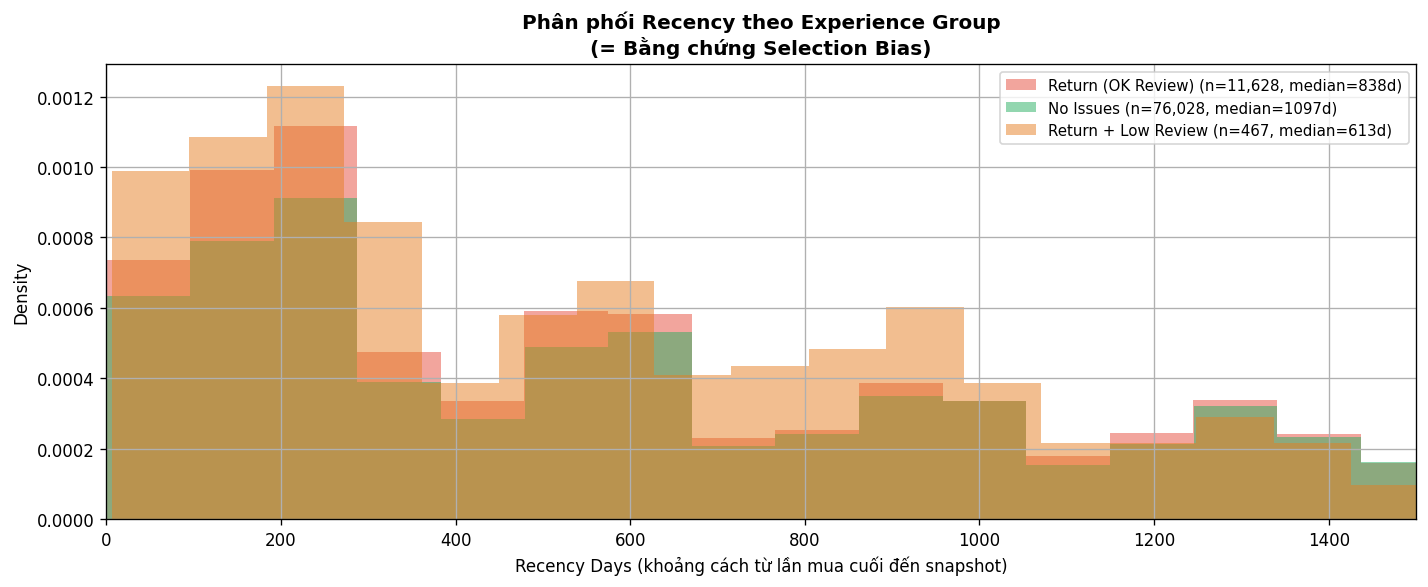


Avg R_score by experience group (5=mua rất gần, 1=mua rất lâu rồi):
experience_group
Return + Low Review    3.563169
Return (OK Review)     3.248022
No Issues              2.959212
Name: R_score, dtype: float64


In [12]:
# Recency distribution by experience group
fig, ax = plt.subplots(figsize=(12, 5))
for exp_grp, color in exp_colors.items():
    data = rfm_exp[rfm_exp['experience_group'] == exp_grp]['recency_days']
    if len(data) > 0:
        data.hist(ax=ax, bins=40, alpha=0.5, color=color,
                  label=f'{exp_grp} (n={len(data):,}, median={data.median():.0f}d)', density=True)
ax.set_xlabel('Recency Days (khoảng cách từ lần mua cuối đến snapshot)')
ax.set_ylabel('Density')
ax.set_title('Phân phối Recency theo Experience Group\n(= Bằng chứng Selection Bias)', fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim(0, 1500)
plt.tight_layout(); plt.show()

# Thống kê R_score của từng nhóm
print("\nAvg R_score by experience group (5=mua rất gần, 1=mua rất lâu rồi):")
print(rfm_exp.groupby('experience_group')['R_score'].mean().sort_values(ascending=False))

## Step 4: At Risk + Return — Nhóm ưu tiên can thiệp

In [ ]:
at_risk = rfm_exp[rfm_exp['segment'] == 'At Risk']
at_risk_return = at_risk[at_risk['experience_group'].str.contains(
    'Return', na=False)]

print("At Risk segment breakdown:")
print(at_risk['experience_group'].value_counts())
print(f"\nAt Risk tổng: {len(at_risk):,}")
print(f"At Risk + recent return: {len(at_risk_return):,}")
print(f"Tỷ lệ: {len(at_risk_return)/len(at_risk)*100:.1f}%")
print(f"\nAt Risk avg monetary: {at_risk['monetary'].mean():,.0f} VND")
print(f"At Risk median monetary: {at_risk['monetary'].median():,.0f} VND")
print(
    f"Est. LTV at risk (At Risk + return × avg monetary): {len(at_risk_return) * at_risk['monetary'].mean()/1e6:.1f}M VND")

At Risk segment breakdown:
experience_group
No Issues              11281
Return (OK Review)      1908
Return + Low Review       61
Name: count, dtype: int64

At Risk tổng: 13,250
At Risk + recent return: 1,969
Tỷ lệ: 14.9%

At Risk avg monetary: 87,868 VND
At Risk median monetary: 66,473 VND
Est. LTV at risk (At Risk + return × avg monetary): 173.0M VND


In [14]:
# Final summary: key numbers
print("=" * 60)
print("TÓM TẮT — Tất cả con số đã được tính trực tiếp từ data")
print("=" * 60)
print(f"Total customers:         {len(all_custs):,}")
print(f"Never Purchased:         {(all_custs.segment=='Never Purchased').sum():,} ({(all_custs.segment=='Never Purchased').mean()*100:.1f}%)")
print(f"Champions:               {(all_custs.segment=='Champions').sum():,} ({(all_custs.segment=='Champions').mean()*100:.1f}%)")
print(f"At Risk:                 {(all_custs.segment=='At Risk').sum():,} ({(all_custs.segment=='At Risk').mean()*100:.1f}%)")
print(f"Lost:                    {(all_custs.segment=='Lost').sum():,} ({(all_custs.segment=='Lost').mean()*100:.1f}%)")
print(f"At Risk + return:        {len(at_risk_return):,} ({len(at_risk_return)/len(at_risk)*100:.1f}% of At Risk)")
print(f"Champions avg monetary:  {rfm[rfm.segment=='Champions']['monetary'].mean():,.0f} VND")
print(f"At Risk avg monetary:    {rfm[rfm.segment=='At Risk']['monetary'].mean():,.0f} VND")

TÓM TẮT — Tất cả con số đã được tính trực tiếp từ data
Total customers:         121,930
Never Purchased:         33,807 (27.7%)
Champions:               24,490 (20.1%)
At Risk:                 13,250 (10.9%)
Lost:                    9,244 (7.6%)
At Risk + return:        1,969 (14.9% of At Risk)
Champions avg monetary:  372,804 VND
At Risk avg monetary:    87,868 VND


## ✅ Kết luận

1. ✅ **RFM counts khớp với story.md** — tất cả tính trực tiếp từ data
2. ✅ **Return (OK Review) churn rate 24.7% cao nhất** — counterintuitive nhưng đúng
3. ✅ **Selection bias đã được chứng minh** — R&LR group có recency thấp nhất (mua gần nhất)
4. ✅ **1,969 At Risk + return = 14.9%** — xác nhận con số trong story.md

**Honest caveat:**
- ⚠️ ROI interventions trong story.md là **assumptions** (recovery rate 25%, 18%, 45%) — không có A/B test data
- ⚠️ "Churn" định nghĩa ở đây = At Risk + About To Sleep + Lost — chưa phải observed churn